In [ ]:
import tensorflow as tf

In [ ]:
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

In [ ]:
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

In [ ]:
from google.colab import drive
drive.flush_and_unmount()


Drive not mounted, so nothing to flush and unmount.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
!ls "/content/drive/MyDrive"

 1000622931.jpg
'10 th result .pdf'
'12th result .pdf'
'3 and 4 result .pdf'
'7 th sem result '
'Application of Forecasting, Regression and Time Series Models.pdf'
 blank.pdf
'Capgemini Snipets by Rehan NEW.pptx'
 Classroom
'Colab Notebooks'
 Copy_of_Exp06.ipynb
'Copy of experi no.10....sp.cpp'
'crc1 (1).cpp'
 crc1.cpp
'Day 5.zip'
'DL Cerificate.pdf'
'Document from Pornima.pdf'
'Document from Sanjana Patil'
'Document from Sanjana Patil (1)'
'Document from Sanjana Patil (2)'
'Elliot Intership (1).pdf'
'Elliot Intership (2).pdf'
'Elliot Intership.pdf'
 exp.10.pdf
'Exp 5.ipynb'
'Experiment 8.pdf'
'experiment no.6......new ...sp.cpp'
'experi no.10....sp.cpp'
'explain tuple relation calculus and domain relati....gsheet'
"I am sharing 'sanjana.pdf' with you from WPS Office"
"I am sharing 'SHEET NO.4.pdf' with you from WPS Office"
'IBM Resume.pdf'
 IMG_20230207_130539.jpg
'IMG-20250215-WA0000 (1).jpg'
 IMG-20250215-WA0000.jpg
'Internship Certificate - Sanjana Patil.pdf'
'Internship_Report_22U

In [ ]:
!ls "/content/drive/MyDrive/Plant Disease/PlantVillage"

Pepper__bell___Bacterial_spot  Tomato_healthy
Pepper__bell___healthy	       Tomato_Late_blight
Potato___Early_blight	       Tomato_Leaf_Mold
Potato___healthy	       Tomato_Septoria_leaf_spot
Potato___Late_blight	       Tomato_Spider_mites_Two_spotted_spider_mite
test			       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus


In [ ]:
# Set the dataset directory
train_dir = "/content/drive/MyDrive/Plant Disease/PlantVillage"

# Add validation split inside ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Create train and validation generators
train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# View class labels
print("Class labels:", train_set.class_indices)

Found 16545 images belonging to 16 classes.
Found 4128 images belonging to 16 classes.
Class labels: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14, 'test': 15}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(train_set.class_indices), activation='softmax')
])

from tensorflow.keras.optimizers import Adam  # ✅ Add this line

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,754,000 (10.51 MB)

 Trainable params: 2,753,040 (10.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
from tensorflow.keras.optimizers import Adam

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),   # slightly higher LR for faster learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model (simplified & faster)
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=20,

    steps_per_epoch=len(train_set),
    validation_steps=len(val_set),
    verbose=1
)

Epoch 1/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 9818s 19s/step - accuracy: 0.4460 - loss: 2.2911 - val_accuracy: 0.4787 - val_loss: 2.0186
Epoch 2/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1232s 2s/step - accuracy: 0.6332 - loss: 1.2004 - val_accuracy: 0.6286 - val_loss: 1.5880
Epoch 3/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1312s 2s/step - accuracy: 0.7152 - loss: 0.9308 - val_accuracy: 0.8009 - val_loss: 0.6428
Epoch 4/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1270s 2s/step - accuracy: 0.7566 - loss: 0.7858 - val_accuracy: 0.7224 - val_loss: 1.0484
Epoch 5/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1228s 2s/step - accuracy: 0.8135 - loss: 0.6101 - val_accuracy: 0.7493 - val_loss: 0.8538
Epoch 6/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1352s 3s/step - accuracy: 0.8264 - loss: 0.5688 - val_accuracy: 0.6635 - val_loss: 1.3634
Epoch 7/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1265s 2s/step - accuracy: 0.8481 - loss: 0.4974 - val_accuracy: 0.8978 - val_loss: 0.3388
Epoch 8/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1261s 2s/step - accuracy: 0.8735 - loss: 0.4216 -

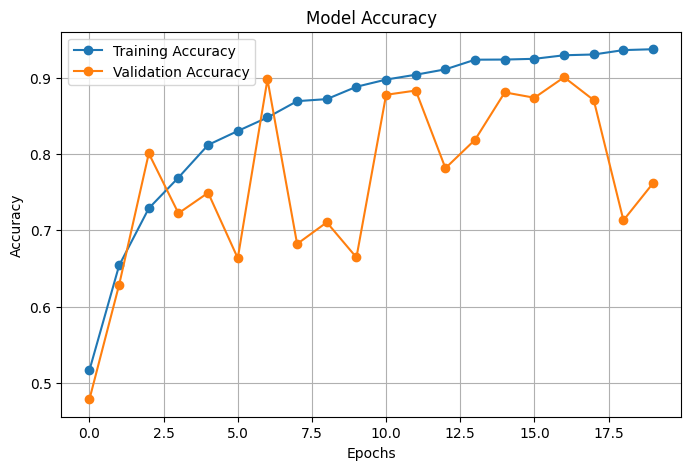

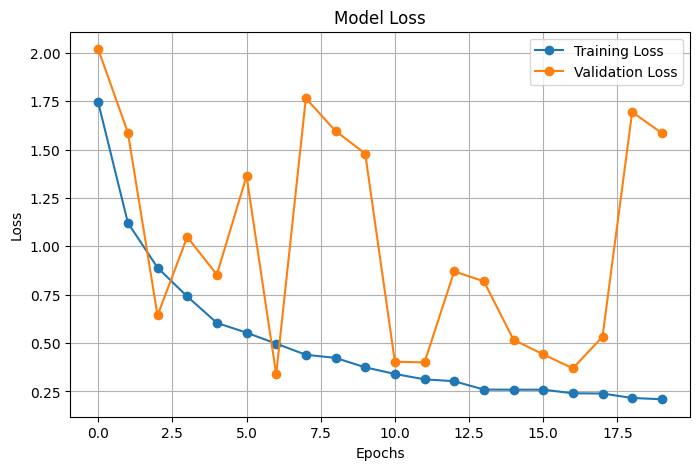

In [14]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
class_names = list(train_set.class_indices.keys())

with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

In [16]:
model.save("plant_disease_model.keras")

In [17]:
!ls "/content/drive/MyDrive/Plant Disease/PlantVillage/test"

test


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


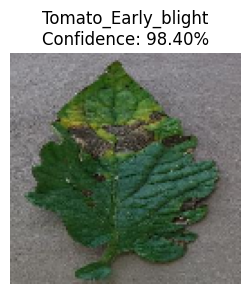

In [24]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_and_show(image_path):
    # Load & preprocess
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_batch)
    index = np.argmax(pred)
    confidence = np.max(pred) * 100
    predicted_class = class_names[index]

    # Show image (reduced size)
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array)
    plt.axis("off")
    plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

# Example
predict_and_show("/content/drive/MyDrive/Plant Disease/PlantVillage/test/test/img1.JPG")